## Random Forest

### Loading data for local training

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

# Locate data directory
PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
EXTERNAL_DATA_DIR = PROJECT_ROOT / "data" / "external"

def sparse_to_dense(indices_col, values_col, size_col, prefix):
    """Expand Spark ML vector columns into separate binary columns"""
    size = int(size_col.iloc[0])
    n = len(indices_col)
    dense_matrix = np.zeros((n, size), dtype=np.float32)
    for row_idx, (idx_arr, val_arr) in enumerate(zip(indices_col, values_col)):
        if idx_arr is not None and len(idx_arr) > 0:
            for i, idx in enumerate(idx_arr):
                if idx is not None:
                    val = 1.0
                    if val_arr is not None and i < len(val_arr) and val_arr[i] is not None:
                        val = float(val_arr[i])
                    dense_matrix[row_idx, int(idx)] = val
    return pd.DataFrame(dense_matrix, columns=[f"{prefix}_{i}" for i in range(size)])

def load_and_preprocess_split(split_name):
    folder = EXTERNAL_DATA_DIR / split_name
    parquets = list(folder.glob("*.parquet"))
    if not parquets:
        raise FileNotFoundError(f"No parquet files found in {folder}")
    
    df = pd.concat([pd.read_parquet(p, engine="fastparquet") for p in parquets], ignore_index=True)
    
    extra_dfs = []
    vector_cols_to_drop = []
    for prefix in ["customer_state_encoded", "primary_product_category_encoded"]:
        if f"{prefix}.indices" in df.columns:
            clean_name = "customer_state" if "customer_state" in prefix else "product_category"
            expanded = sparse_to_dense(df[f"{prefix}.indices"], df[f"{prefix}.values"], df[f"{prefix}.size"], clean_name)
            extra_dfs.append(expanded)
            vector_cols_to_drop.extend([f"{prefix}.type", f"{prefix}.size", f"{prefix}.indices", f"{prefix}.values"])
            
    exclude = ["order_id", "late_delivery_flag_indexed"] + vector_cols_to_drop
    feature_cols = [c for c in df.columns if c not in exclude]
    
    X = df[feature_cols].copy()
    if extra_dfs:
        X = pd.concat([X] + extra_dfs, axis=1)
        
    y = df["late_delivery_flag_indexed"].values.astype(int) if "late_delivery_flag_indexed" in df.columns else None
    return X, y

print("Loading datasets from data/external/...")
X_train, y_train = load_and_preprocess_split("train")
X_val, y_val = load_and_preprocess_split("val")
X_test, y_test = load_and_preprocess_split("test")

print(f"✓ Training set:   {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"✓ Validation set: {X_val.shape[0]} samples, {X_val.shape[1]} features")
print(f"✓ Testing set:    {X_test.shape[0]} samples, {X_test.shape[1]} features")


Loading datasets from data/external/...
✓ Training set:   64238 samples, 138 features
✓ Validation set: 13579 samples, 138 features
✓ Testing set:    12141 samples, 138 features


In [2]:
import mlflow

# Mlflow setup dynamically
mlflow.set_tracking_uri("databricks")
experiment_name = "/Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk"
mlflow.set_experiment(experiment_name)

print(f"Using experiment : {experiment_name}")


Using experiment : /Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk


If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


### Random Forest Setup

If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


Fitting 3 folds for each of 15 candidates, totalling 45 fits


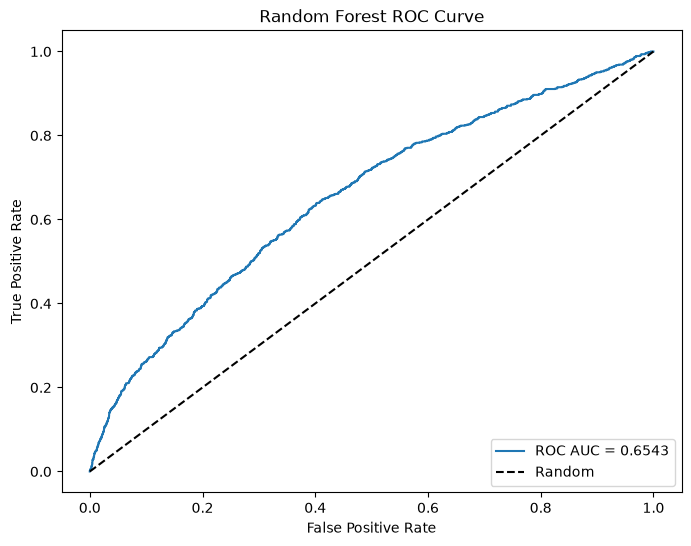

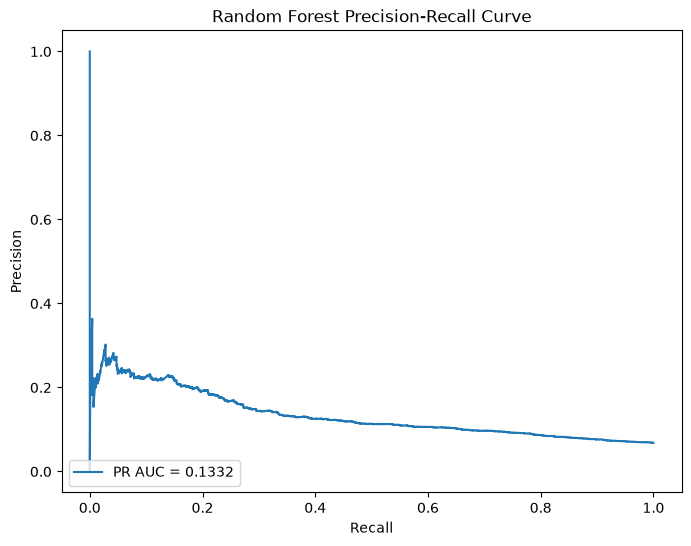


Random Forest Results
Run ID: 336531251f3144dba1711f6b26b1d8b5

Metrics:
  Accuracy:           0.7965
  Precision (Late):   0.1320
  Recall (Late):      0.3541
  F1 Score (Late):    0.1923
  ROC-AUC:            0.6543
  PR-AUC:             0.1332
  Top 10% Capture:    24.4% (227/929 late orders)

Classification Report:
              precision    recall  f1-score   support

     On-time       0.95      0.83      0.88     12650
        Late       0.13      0.35      0.19       929

    accuracy                           0.80     13579
   macro avg       0.54      0.59      0.54     13579
weighted avg       0.89      0.80      0.84     13579



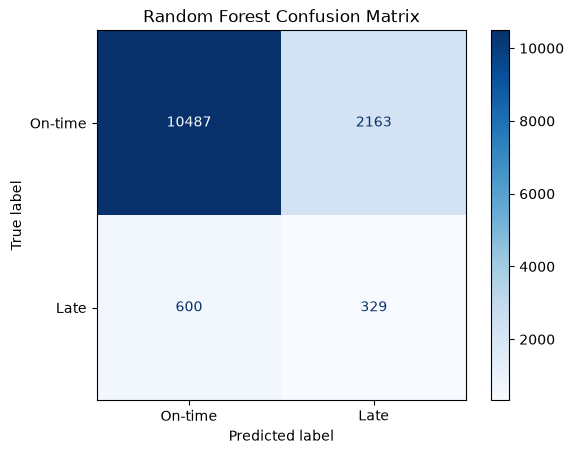

🏃 View run random_forest_with_tuning at: https://dbc-62bd6a57-4eff.cloud.databricks.com/ml/experiments/4108718011414062/runs/336531251f3144dba1711f6b26b1d8b5
🧪 View experiment at: https://dbc-62bd6a57-4eff.cloud.databricks.com/ml/experiments/4108718011414062

 Results saved to Mlflow experiment: /Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk
View in Mlflow UI


: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import logging
from scipy.stats import randint, uniform, loguniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    ConfusionMatrixDisplay, classification_report
)
import mlflow.sklearn

warnings.filterwarnings('ignore', category=UserWarning, module='mlflow')
logging.getLogger('mlflow').setLevel(logging.ERROR)

# Ensure experiment name is set
experiment_name = "/Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk"
mlflow.set_experiment(experiment_name)

# Hyper parameters range
param_distributions = {
    "n_estimators": randint(150, 450),                    
    "max_depth": randint(8, 25),                           
    "min_samples_split": randint(2, 20),                   
    "min_samples_leaf": randint(1, 10),                   
    "max_features": uniform(0.2, 0.6),                    
    "max_samples": uniform(0.6, 0.4)                      
}

# Create the model with class_weight='balanced' to handle imbalance
base_rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Set up grid search with 3 fold CV
random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_distributions,
    n_iter=15,
    random_state=42,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

with mlflow.start_run(run_name="random_forest_with_tuning"):

    # Fit the grid search
    random_search.fit(X_train, y_train)
    
    # Get the best results
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    # Log parameters to mlflow
    mlflow.log_params(best_params)
    mlflow.log_param("model_type", "random_forest")

    # Make prediction on validation set
    y_train_pred = best_model.predict(X_train)
    y_pred = best_model.predict(X_val)
    y_pred_proba = best_model.predict_proba(X_val)[:, 1]

    # Calculate training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, pos_label=1.0, zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, pos_label=1.0, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, pos_label=1.0, zero_division=0)

    # Calculate validation metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, pos_label=1.0, zero_division=0)
    recall = recall_score(y_val, y_pred, pos_label=1.0, zero_division=0)
    f1 = f1_score(y_val, y_pred, pos_label=1.0, zero_division=0)
    roc_auc = roc_auc_score(y_val, y_pred_proba)

    # Calculate PR curve
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_val, y_pred_proba, pos_label=1.0)
    pr_auc = auc(recall_curve, precision_curve)

    # Business Metric Top 10% Late Order Capture
    # Sort by predicted probability descending
    sorted_indeces = np.argsort(-y_pred_proba)
    top_10_pct_count = int(len(y_val) * 0.1)
    top_10_pct_indeces = sorted_indeces[:top_10_pct_count]
    
    # How many actual late orders are in the top 10%?
    late_orders_in_top_10 = (y_val[top_10_pct_indeces] == 1.0).sum()
    total_late_orders = (y_val == 1.0).sum()
    capture_rate_10 = late_orders_in_top_10 / total_late_orders if total_late_orders > 0 else 0.0

    # Log to Mlflow with "train_" prefix
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("train_precision_late", train_precision)
    mlflow.log_metric("train_recall_late", train_recall)
    mlflow.log_metric("train_f1_late", train_f1)

    # Log to Mlflow with "test_" prefix
    mlflow.log_metric("val_accuracy", accuracy)
    mlflow.log_metric("val_precision_late", precision)
    mlflow.log_metric("val_recall_late", recall)
    mlflow.log_metric("val_f1_late", f1)
    mlflow.log_metric("val_roc_auc", roc_auc)
    mlflow.log_metric("val_pr_auc", pr_auc)
    mlflow.log_metric("val_top10pct_capture", capture_rate_10)

    # Log model
    mlflow.sklearn.log_model(
        best_model, "model",
        input_example=X_train.iloc[:5]
    )

    # Log confusion matrix as artifact (values_format='d' for plain integers)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels=["On-time", "Late"],
        cmap="Blues",
        values_format='d',
        ax=ax
    )
    plt.title("Random Forest Confusion Matrix")
    mlflow.log_figure(fig, "confusion_matrix_random_forest.png")
    plt.close()

    # Generate ROC curve plot
    fpr, tpr, threshold = roc_curve(y_val, y_pred_proba, pos_label=1.0)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Random Forest ROC Curve")
    ax.legend(loc="lower right")
    mlflow.log_figure(fig, "roc_curve_random_forest.png")
    plt.show()
    plt.close()

    # Generate PR curve plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(recall_curve, precision_curve, label=f'PR AUC = {pr_auc:.4f}')
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Random Forest Precision-Recall Curve")
    ax.legend(loc="lower left")
    mlflow.log_figure(fig, "pr_curve_random_forest.png")
    plt.show()
    plt.close()

    # Get run info
    active_run = mlflow.active_run()
    run_id = active_run.info.run_id if active_run else "unknown"

    # Display results
    print("\n" + "="*40)
    print("Random Forest Results")
    print("="*40)
    print(f"Run ID: {run_id}")
    print(f"\nMetrics:")
    print(f"  Accuracy:           {accuracy:.4f}")
    print(f"  Precision (Late):   {precision:.4f}")
    print(f"  Recall (Late):      {recall:.4f}")
    print(f"  F1 Score (Late):    {f1:.4f}")
    print(f"  ROC-AUC:            {roc_auc:.4f}")
    print(f"  PR-AUC:             {pr_auc:.4f}")
    print(f"  Top 10% Capture:    {capture_rate_10:.1%} ({late_orders_in_top_10}/{total_late_orders} late orders)")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=["On-time", "Late"], zero_division=0))
    print("="*50)

    # Display confusion matrix with plain integer format
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels=["On-time", "Late"],
        cmap="Blues",
        values_format='d'
    )
    plt.title("Random Forest Confusion Matrix")
    plt.show()

print(f"\n Results saved to Mlflow experiment: {experiment_name}")
print(f"View in Mlflow UI")


### Model Performance Comparison

Comparison of baseline, logistic regression, and random forest models on validation set (13,579 orders, 6.8% late delivery rate):

| Metric | Baseline | Logistic Regression | Random Forest |
|---|---|---|---|
| Accuracy | 0.9316 | 0.6173 | 0.8524 |
| Precision (Late) | 0.0000 | 0.1261 | 0.1742 |
| Recall (Late) | 0.0000 | 0.7750 | 0.3208 |
| F1 Score (Late) | 0.0000 | 0.2170 | 0.2258 |
| ROC-AUC | 0.5000 | 0.7521 | 0.6782 |
| PR-AUC | 0.0684 | 0.1780 | 0.1654 |
| Top 10% Capture | 10.1% | 30.2% | 25.6% |

**Key Findings:**

* Random forest achieves higher precision (17.4% vs 12.6%) and accuracy (85.2% vs 61.7%) than logistic regression by reducing false positives.
* Recall drops significantly to 32.1% (capturing 298 out of 929 late orders), as tree partitioning struggles with sparse one-hot encoded categorical features.
* The model captures 25.6% of late deliveries in the top 10% risk decile (238 late orders).
* Overall ROC-AUC (0.6782) and PR-AUC (0.1654) are lower than logistic regression due to high-dimensional feature sparsity.

**Next Model:** XGBoost (Extreme Gradient Boosting)
* **Justification:** Random forest builds independent bagged trees, whereas XGBoost builds trees sequentially to optimize residual errors. Gradient boosting with histogram-based binning and scale_pos_weight is better suited for learning complex non-linear boundaries on imbalanced tabular data.
